Завдання 1
Загрузити датасет Global YouTube Statistics 2023

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/global-youtube-statistics-2023")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'global-youtube-statistics-2023' dataset.
Path to dataset files: /kaggle/input/global-youtube-statistics-2023


Виконайте наступні завдання:
1. Прочитайте CSV файл

In [2]:
import pandas as pd
import os

print(os.listdir("/kaggle/input/global-youtube-statistics-2023"))

['Global YouTube Statistics.csv']


In [7]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/global-youtube-statistics-2023/Global YouTube Statistics.csv",
    encoding="latin1"
)

2. Виведіть перші п'ять рядків

In [8]:
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


3. Виведіть розміри датасету, перевірте наявність пропусків, дублікатів.

In [9]:
print("Shape:", df.shape)

print("\nMissing values:\n", df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

Shape: (995, 28)

Missing values:
 rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month            

[4. Якщо є пропуски, замінить тип даних на float і середнє значення за
стовпцем.\]

In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols] = df[num_cols].astype(float)

df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.mean()))

5. Ще раз перевірте кількість пропусків.

In [15]:
df.isnull().sum()

,0
rank,0
Youtuber,0
subscribers,0
video views,0
category,46
Title,0
uploads,0
Country,122
Abbreviation,122
channel_type,30


6. Перевірте, скільки унікальних країн представлено у колонці "Country"




In [16]:
df["Country"].nunique()

49

7. Побудуйте діаграму розподілу переглядів (використовуйте kind='hist'):

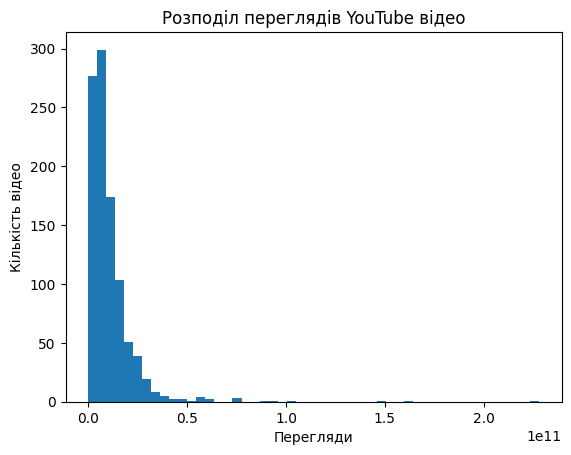

In [17]:
import matplotlib.pyplot as plt

df["video views"].plot(kind="hist", bins=50)

plt.title("Розподіл переглядів YouTube відео")
plt.xlabel("Перегляди")
plt.ylabel("Кількість відео")

plt.show()

8. Визначте максимальну, мінімальну, середню кількість переглядів
(використовуйте методи max, min, mean)

In [22]:
max_views = df["video views"].max()
min_views = df["video views"].min()
mean_views = df["video views"].mean()

print("Максимальні перегляди:", max_views)
print("Мінімальні перегляди:", min_views)
print("Середня кількість переглядів:", mean_views)

Максимальні перегляди: 228000000000.0
Мінімальні перегляди: 0.0
Середня кількість переглядів: 11039537052.03819


9. Знайдіть країну, де найбільше відео було завантажено на YouTube

In [23]:
df["Country"].value_counts().idxmax()

'United States'

10. Знайдіть відео (виведіть його назву) з найбільшою та найменшою
кількістю завантажень uploads.

In [24]:
max_upload_video = df.loc[df["uploads"].idxmax(), "Title"]
min_upload_video = df.loc[df["uploads"].idxmin(), "Title"]

print("Відео з найбільшою кількістю завантажень:", max_upload_video)
print("Відео з найменшою кількістю завантажень:", min_upload_video)

Відео з найбільшою кількістю завантажень: ABP NEWS
Відео з найменшою кількістю завантажень: Music


Завдання 2.
Зчитати архів Customer Shopping Trends Dataset
Далі працюємо з файлом shopping_trends.csv
Загрузіть цей файл. Перевірте розмір таблиці, наявність пропусків, тип
стовпців. Перейменуйте назви стовпців: Змініть прописні букви на строчні
(маленькі) та пробіл на підкреслення.

In [26]:
from google.colab import files
uploaded = files.upload()

Saving shopping_trends.csv to shopping_trends.csv


In [27]:
import pandas as pd

df = pd.read_csv("shopping_trends.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [28]:
print("Розмір таблиці:", df.shape)

print("\nПропуски:\n", df.isnull().sum())

print("\nТипи даних:\n", df.dtypes)

df.columns = df.columns.str.lower().str.replace(" ", "_")

print("\nНові колонкиs:\n", df.columns)

print("\nПеревірка пропусків:\n", df.isnull().sum())

Розмір таблиці: (3900, 19)

Пропуски:
 Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

Типи даних:
 Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Revi

1. Побудуйте гістограму віку клієнтів, використовуючи Seaborn.

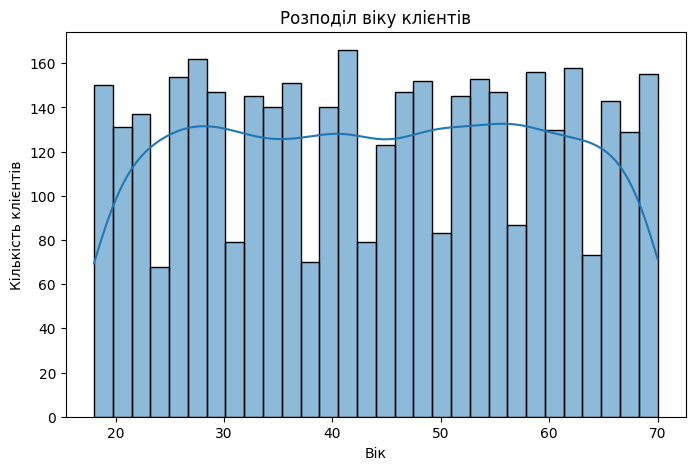

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(data=df, x="age", bins=30, kde=True)

plt.title("Розподіл віку клієнтів")
plt.xlabel("Вік")
plt.ylabel("Кількість клієнтів")

plt.show()

2. Порівняння розподілу покупок за статтею (item_purchased):

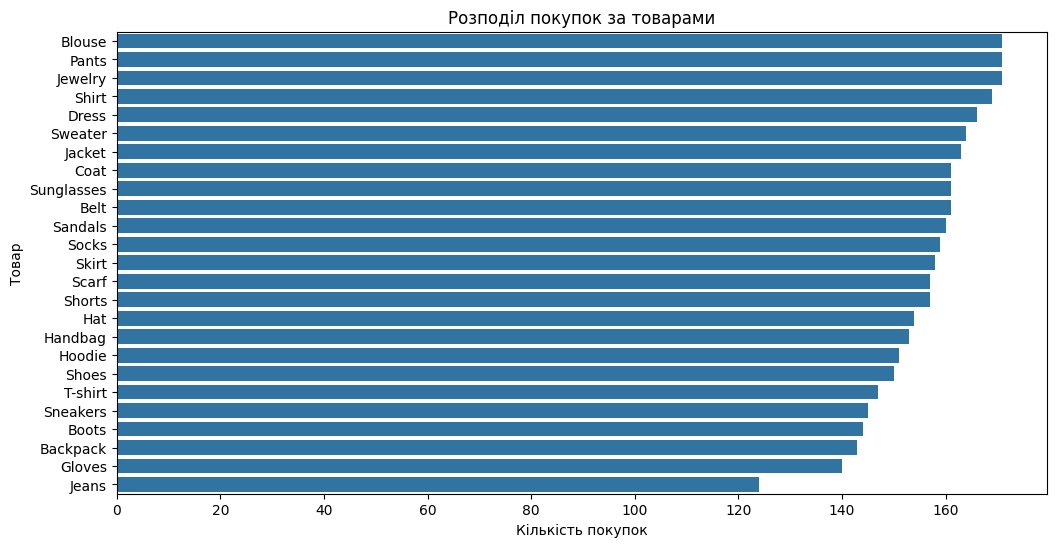

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="item_purchased",
    order=df["item_purchased"].value_counts().index
)

plt.title("Розподіл покупок за товарами")
plt.xlabel("Кількість покупок")
plt.ylabel("Товар")

plt.show()

Створіть стовпчасту діаграму або графік розподілу, щоб порівняти, які
товари покупають клієнти найчастіше.

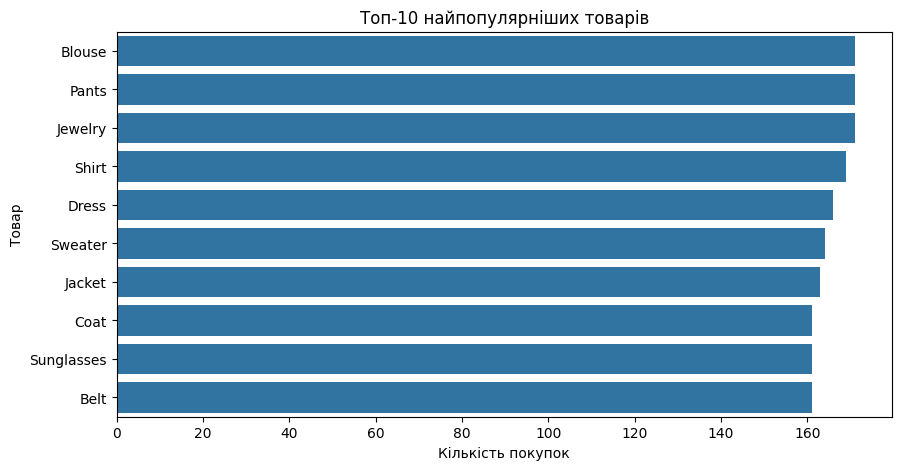

In [32]:
plt.figure(figsize=(10,5))

top_items = df["item_purchased"].value_counts().head(10)

sns.barplot(x=top_items.values, y=top_items.index)

plt.title("Топ-10 найпопулярніших товарів")
plt.xlabel("Кількість покупок")
plt.ylabel("Товар")

plt.show()

4. Залежність між віком та сумою покупок (purchase_amount):

5. Використовуйте scatter plot, щоб візуалізувати залежність між віком та
сумою покупок.

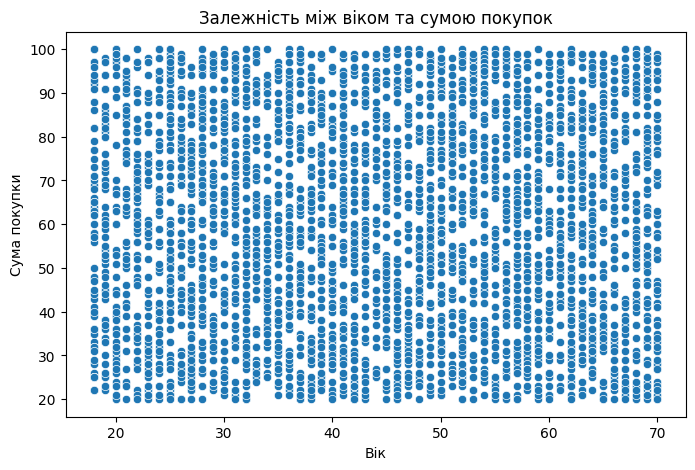

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="purchase_amount_(usd)"
)

plt.title("Залежність між віком та сумою покупок")
plt.xlabel("Вік")
plt.ylabel("Сума покупки")

plt.show()

6. Графік розподілу оцінок товарів (review_rating):

7. Побудуйте графік розподілу оцінок товарів для оцінки якості.

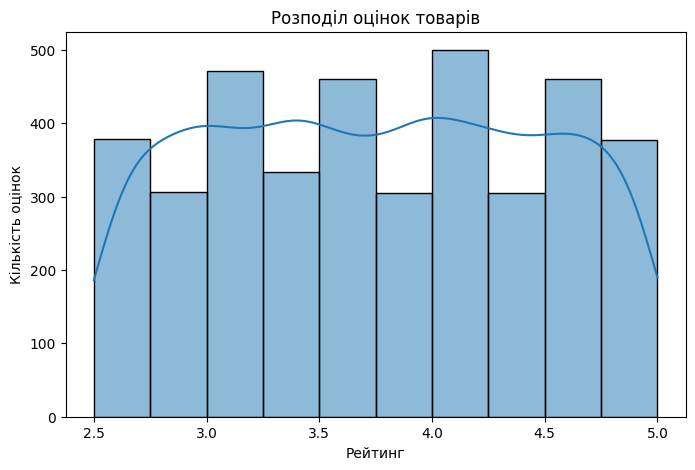

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="review_rating",
    bins=10,
    kde=True
)

plt.title("Розподіл оцінок товарів")
plt.xlabel("Рейтинг")
plt.ylabel("Кількість оцінок")

plt.show()

8. Категоріальна діаграма для статі (gender):

9. Створіть категоріальну діаграму, щоб відобразити розподіл покупок за
статтею.

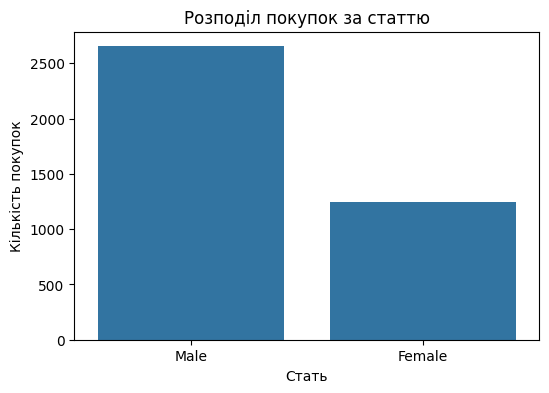

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Розподіл покупок за статтю")
plt.xlabel("Стать")
plt.ylabel("Кількість покупок")

plt.show()

10. Залежність між рейтингом і сумою покупок (review_rating і
purchase_amount) (8 б)

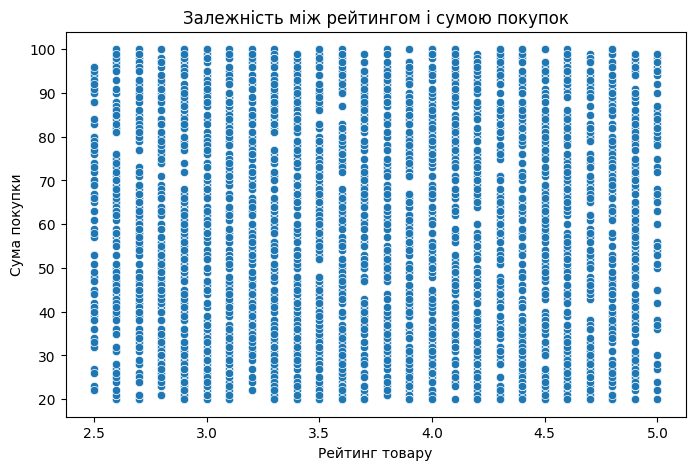

In [37]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="review_rating",
    y="purchase_amount_(usd)"
)

plt.title("Залежність між рейтингом і сумою покупок")
plt.xlabel("Рейтинг товару")
plt.ylabel("Сума покупки")

plt.show()

Завдання 3

Створіть горизонтальну діаграму з мітками на основі даних про
врожайність пшениці (data.wheat()) за допомогою бібліотеки Altair.
Задайте вісь x для врожайності пшениці, вісь y для років, а текстові
мітки відображайте значення врожайності пшениці на відповідних
роках.

In [38]:
!pip install altair vega_datasets

In [39]:
import altair as alt
from vega_datasets import data

wheat = data.wheat()

chart = alt.Chart(wheat).mark_bar().encode(
    x=alt.X("wheat:Q", title="Врожайність пшениці"),
    y=alt.Y("year:O", title="Рік"),
)

text = chart.mark_text(
    align="left",
    baseline="middle",
    dx=3
).encode(
    text="wheat:Q"
)

chart + text

alt.LayerChart(...)

Створіть багатошарову діаграму на основі даних про виробництво
електроенергії в штаті Айова (data.iowa_electricity()) за допомогою
бібліотеки Altair . Вісь x представляє роки, вісь y відображає чисте
виробництво електроенергії (net_generation), а кожен шар діаграми
позначає різні джерела енергії (source). Встановіть прозорість (opacity)
для стовпців на рівні 0.7.

In [40]:
import altair as alt
from vega_datasets import data

iowa = data.iowa_electricity()

chart = alt.Chart(iowa).mark_bar(opacity=0.7).encode(
    x=alt.X("year:O", title="Рік"),
    y=alt.Y("net_generation:Q", title="Чисте виробництво електроенергії"),
    color=alt.Color("source:N", title="Джерело енергії")
)

chart

alt.Chart(...)

Створіть графік за допомогою бібліотеки Plotly (scatter plot) для даних
ірисів (iris dataset), де:
Вісь X (x-axis) відповідає ширині чашелистика (sepal width).
Вісь Y (y-axis) відповідає довжині чашелистика (sepal length).
Кожен пункт на графіку має розмір, який залежить від довжини
пелюстки (petal length).
Кожен пункт на графіку має різний колір в залежності від виду
(species).
При наведенні на пункт повинні відображатися додаткові дані, такі як
ширина пелюстки (petal width)

In [42]:
import plotly.express as px

df = px.data.iris()

fig = px.scatter(
    df,
    x="sepal_width",
    y="sepal_length",
    size="petal_length",
    color="species",
    hover_data=["petal_width"],
    title="Iris Dataset: залежність параметрів квітки"
)

fig.show()